In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

In [29]:
df = pd.read_csv("../data/nasdaq/csv/AAPL.csv")

df["Date"] = pd.to_datetime(
    df["Date"],
    dayfirst=True,
    errors="coerce"
)

df = df.dropna(subset=["Date"])

df = df.sort_values("Date").reset_index(drop=True)

df.head()

,Date,Low,Open,Volume,High,Close,Adjusted Close
0,1980-12-12,0.128348,0.128348,469033600,0.128906,0.128348,0.099874
1,1980-12-15,0.121652,0.122210,175884800,0.122210,0.121652,0.094663
2,1980-12-16,0.112723,0.113281,105728000,0.113281,0.112723,0.087715
3,1980-12-17,0.115513,0.115513,86441600,0.116071,0.115513,0.089886
4,1980-12-18,0.118862,0.118862,73449600,0.119420,0.118862,0.092492


In [30]:
features = [
    "Low",
    "Open",
    "Volume",
    "High",
    "Close",
    "Adjusted Close"
]

target_col = "Close"

close_index = features.index(target_col)

data = df[features].copy()

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(data)

print(scaled_data.shape)

(10590, 6)


In [31]:
def chronological_split(X, y, train_ratio=0.7, val_ratio=0.15):

    train_size = int(len(X) * train_ratio)

    val_size = int(len(X) * val_ratio)

    X_train = X[:train_size]
    y_train = y[:train_size]

    X_val = X[train_size:train_size + val_size]
    y_val = y[train_size:train_size + val_size]

    X_test = X[train_size + val_size:]
    y_test = y[train_size + val_size:]

    return X_train, X_val, X_test, y_train, y_val, y_test

In [32]:
def build_lstm_model(
    window_size,
    num_features,
    output_size
):

    model = Sequential()

    model.add(
        LSTM(
            64,
            return_sequences=True,
            input_shape=(window_size, num_features)
        )
    )

    model.add(Dropout(0.2))

    model.add(
        LSTM(
            32,
            return_sequences=False
        )
    )

    model.add(Dropout(0.2))

    model.add(Dense(64, activation='relu'))

    model.add(Dense(output_size))

    model.compile(
        optimizer=Adam(learning_rate=0.0005),
        loss='mse',
        metrics=['mae']
    )

    return model

In [33]:
def plot_training_history(history, title):

    plt.figure(figsize=(12,5))

    plt.plot(
        history.history["loss"],
        label="Train Loss"
    )

    plt.plot(
        history.history["val_loss"],
        label="Validation Loss"
    )

    plt.yscale("log")

    plt.title(title)

    plt.xlabel("Epoch")

    plt.ylabel("Loss (log scale)")

    plt.legend()

    plt.show()

In [34]:
def evaluate_prediction(
    y_true,
    y_pred,
    title
):

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    print(title)

    print("RMSE:", rmse)

    print("MAE:", mae)

    return rmse, mae

In [35]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

In [36]:
def create_kth_day_dataset(
    scaled_data,
    window_size,
    close_index,
    k
):

    X = []
    y = []

    for i in range(
        window_size,
        len(scaled_data) - k + 1
    ):

        X.append(
            scaled_data[i-window_size:i]
        )

        y.append(
            scaled_data[i + k - 1, close_index]
        )

    return np.array(X), np.array(y)

In [37]:
window_size = 30

k_day = 7

X_1_2, y_1_2 = create_kth_day_dataset(
    scaled_data,
    window_size,
    close_index,
    k_day
)

print(X_1_2.shape)
print(y_1_2.shape)

(10554, 30, 6)
(10554,)


In [38]:
X_train_1_2, X_val_1_2, X_test_1_2, \
y_train_1_2, y_val_1_2, y_test_1_2 = chronological_split(
    X_1_2,
    y_1_2
)

In [39]:
model_task_1_2_lstm = build_lstm_model(
    window_size,
    len(features),
    1
)

model_task_1_2_lstm.summary()

d:\Study Documents\Fulbright\2026 Spring\Deep Learning for Artificial Intelligence\DL_Final_Project\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 30, 64)         │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,769 (128.00 KB)

 Trainable params: 32,769 (128.00 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
history_1_2_lstm = model_task_1_2_lstm.fit(
    X_train_1_2,
    y_train_1_2,
    validation_data=(
        X_val_1_2,
        y_val_1_2
    ),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
231/231 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - loss: 6.4842e-06 - mae: 0.0015 - val_loss: 6.9516e-05 - val_mae: 0.0061
Epoch 2/100
231/231 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: 2.8763e-06 - mae: 0.0011 - val_loss: 2.3478e-04 - val_mae: 0.0134
Epoch 3/100
231/231 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 2.3785e-06 - mae: 9.7551e-04 - val_loss: 2.4715e-04 - val_mae: 0.0138
Epoch 4/100
231/231 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 2.0803e-06 - mae: 8.7700e-04 - val_loss: 2.3679e-04 - val_mae: 0.0133
Epoch 5/100
231/231 ━━━━━━━━━━━━━━━━━━━━ 11s 46ms/step - loss: 2.1860e-06 - mae: 9.3332e-04 - val_loss: 3.2439e-04 - val_mae: 0.0159
Epoch 6/100
231/231 ━━━━━━━━━━━━━━━━━━━━ 15s 66ms/step - loss: 1.9447e-06 - mae: 8.7077e-04 - val_loss: 6.7414e-04 - val_mae: 0.0236
Epoch 7/100
231/231 ━━━━━━━━━━━━━━━━━━━━ 12s 50ms/step - loss: 2.0856e-06 - mae: 9.2647e-04 - val_loss: 4.2398e-04 - val_mae: 0.0181
Epoch 8/100
231/231 ━━━━━━━━━━━━━━━━━━━━ 11s 50ms/step - loss: 1.9271e-06 - mae: 

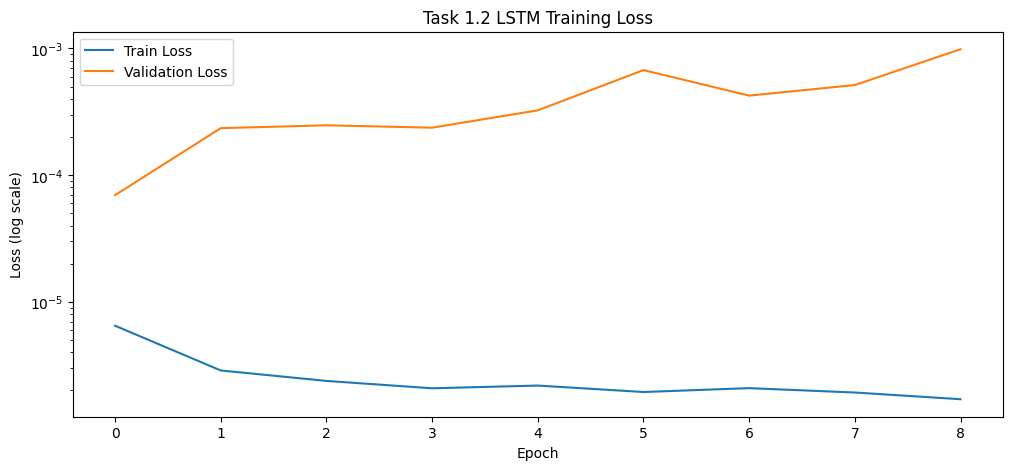

In [41]:
plot_training_history(
    history_1_2_lstm,
    "Task 1.2 LSTM Training Loss"
)

In [42]:
pred_1_2_lstm = model_task_1_2_lstm.predict(
    X_test_1_2
)

rmse_1_2_lstm, mae_1_2_lstm = evaluate_prediction(
    y_test_1_2,
    pred_1_2_lstm,
    "Task 1.2 LSTM Evaluation"
)

50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step
Task 1.2 LSTM Evaluation
RMSE: 0.11277482554671038
MAE: 0.07376566297440022


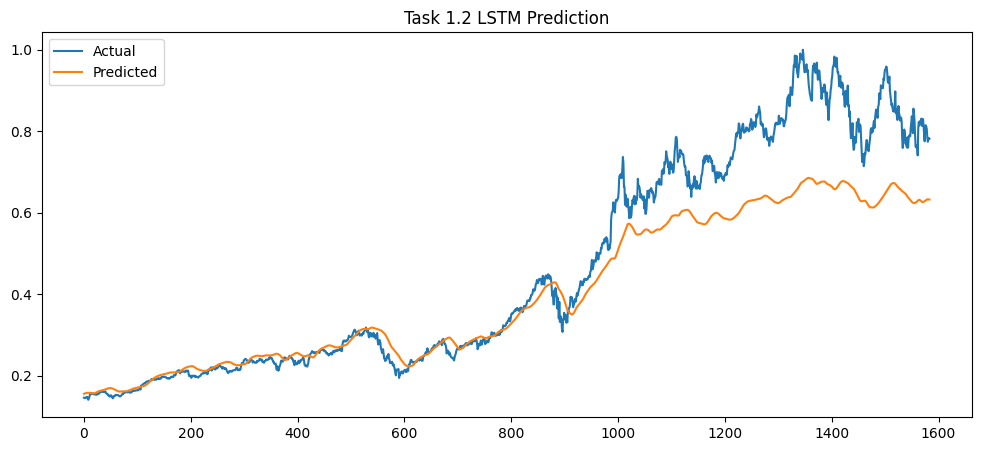

In [43]:
plt.figure(figsize=(12,5))

plt.plot(
    y_test_1_2,
    label="Actual"
)

plt.plot(
    pred_1_2_lstm,
    label="Predicted"
)

plt.title(
    "Task 1.2 LSTM Prediction"
)

plt.legend()

plt.show()

In [44]:
def create_k_days_dataset(
    scaled_data,
    window_size,
    close_index,
    k
):

    X = []
    y = []

    for i in range(
        window_size,
        len(scaled_data) - k + 1
    ):

        X.append(
            scaled_data[i-window_size:i]
        )

        y.append(
            scaled_data[i:i+k, close_index]
        )

    return np.array(X), np.array(y)

In [45]:
k_days = 7

X_1_3, y_1_3 = create_k_days_dataset(
    scaled_data,
    window_size,
    close_index,
    k_days
)

print(X_1_3.shape)
print(y_1_3.shape)

(10554, 30, 6)
(10554, 7)


In [46]:
X_train_1_3, X_val_1_3, X_test_1_3, \
y_train_1_3, y_val_1_3, y_test_1_3 = chronological_split(
    X_1_3,
    y_1_3
)

In [47]:
model_task_1_3_lstm = build_lstm_model(
    window_size,
    len(features),
    k_days
)

model_task_1_3_lstm.summary()

d:\Study Documents\Fulbright\2026 Spring\Deep Learning for Artificial Intelligence\DL_Final_Project\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 30, 64)         │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,159 (129.53 KB)

 Trainable params: 33,159 (129.53 KB)

 Non-trainable params: 0 (0.00 B)

In [48]:
history_1_3_lstm = model_task_1_3_lstm.fit(
    X_train_1_3,
    y_train_1_3,
    validation_data=(
        X_val_1_3,
        y_val_1_3
    ),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
231/231 ━━━━━━━━━━━━━━━━━━━━ 15s 44ms/step - loss: 1.1327e-05 - mae: 0.0018 - val_loss: 9.0541e-05 - val_mae: 0.0071
Epoch 2/100
231/231 ━━━━━━━━━━━━━━━━━━━━ 14s 62ms/step - loss: 3.0818e-06 - mae: 0.0011 - val_loss: 1.7224e-04 - val_mae: 0.0108
Epoch 3/100
231/231 ━━━━━━━━━━━━━━━━━━━━ 10s 43ms/step - loss: 2.4933e-06 - mae: 9.8688e-04 - val_loss: 4.5796e-05 - val_mae: 0.0051
Epoch 4/100
231/231 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - loss: 2.1601e-06 - mae: 9.2318e-04 - val_loss: 7.7301e-05 - val_mae: 0.0067
Epoch 5/100
231/231 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 2.1771e-06 - mae: 9.2376e-04 - val_loss: 1.1742e-04 - val_mae: 0.0086
Epoch 6/100
231/231 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - loss: 1.9718e-06 - mae: 8.8680e-04 - val_loss: 1.5460e-04 - val_mae: 0.0100
Epoch 7/100
231/231 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - loss: 1.7298e-06 - mae: 8.2231e-04 - val_loss: 9.7902e-05 - val_mae: 0.0077
Epoch 8/100
231/231 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - loss: 1.7972e-06 - mae: 8

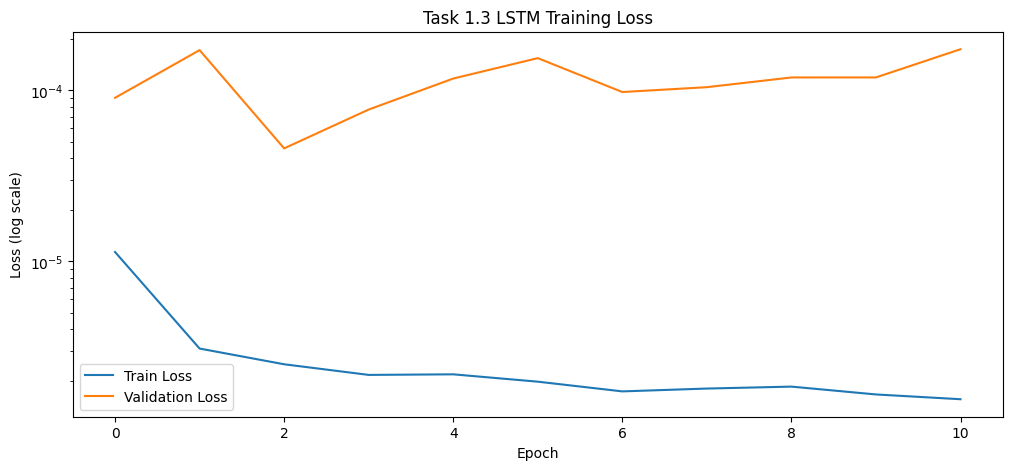

In [49]:
plot_training_history(
    history_1_3_lstm,
    "Task 1.3 LSTM Training Loss"
)

In [50]:
pred_1_3_lstm = model_task_1_3_lstm.predict(
    X_test_1_3
)

rmse_1_3_lstm = np.sqrt(
    mean_squared_error(
        y_test_1_3.flatten(),
        pred_1_3_lstm.flatten()
    )
)

mae_1_3_lstm = mean_absolute_error(
    y_test_1_3.flatten(),
    pred_1_3_lstm.flatten()
)

print("Task 1.3 LSTM")

print("RMSE:", rmse_1_3_lstm)

print("MAE:", mae_1_3_lstm)

50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
Task 1.3 LSTM
RMSE: 0.17330352644880148
MAE: 0.11597182470041612


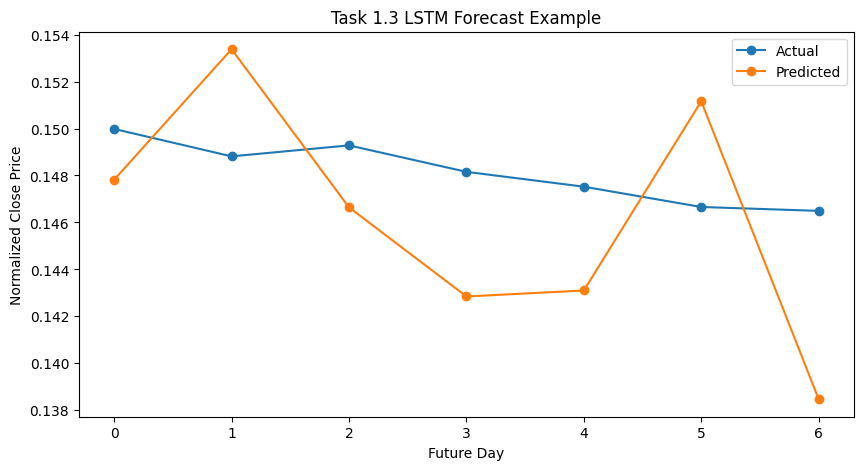

In [51]:
sample_index = 0

plt.figure(figsize=(10,5))

plt.plot(
    y_test_1_3[sample_index],
    marker="o",
    label="Actual"
)

plt.plot(
    pred_1_3_lstm[sample_index],
    marker="o",
    label="Predicted"
)

plt.title(
    "Task 1.3 LSTM Forecast Example"
)

plt.xlabel("Future Day")

plt.ylabel("Normalized Close Price")

plt.legend()

plt.show()

In [52]:
lstm_results = pd.DataFrame({
    "Task": [
        "Task 1.2 - 7th day prediction",
        "Task 1.3 - Next 7 days prediction"
    ],
    "Model": [
        "LSTM",
        "LSTM"
    ],
    "RMSE": [
        rmse_1_2_lstm,
        rmse_1_3_lstm
    ],
    "MAE": [
        mae_1_2_lstm,
        mae_1_3_lstm
    ]
})

lstm_results.to_csv("../results/task1_lstm_results.csv", index=False)

lstm_results

,Task,Model,RMSE,MAE
0,Task 1.2 - 7th day prediction,LSTM,0.112775,0.073766
1,Task 1.3 - Next 7 days prediction,LSTM,0.173304,0.115972
